# Sensor calibration training

Supports both CSV filename formats:
- `log_<distance>cm.csv` for mixed/up+down data in one file
- `log_<distance>cm_<start>_to_<end>.csv` for legacy directional logs
- `log_d6t_<distance>cm_report.csv` for D6T-only refit reports

Direction is parsed only for reference. It is not used as a model feature.


In [86]:
from pathlib import Path
import hashlib
import importlib.util
import json
import math
import re
from pprint import pformat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

ENABLE_CLEANING = True
CLEANING_STRICTNESS = 'medium'
# Train each sensor independently so sensor-specific logs are all usable.

MIN_TEMP = 20.0
MAX_TEMP = 250.0
MAX_STEP_REF = 8.0
MAX_STEP_SENSOR = 15.0
ROBUST_Z_LIMIT = 4.0
ROLLING_WINDOW = 15
ROLLING_DEV_REF = 5.0
ROLLING_DEV_SENSOR = 10.0
MAX_REMOVED_FRACTION_WARNING = 0.20
MAX_MEAN_ABS_PERCENT_OF_GDM = 5.0
EXPORT_COMBINED_CLEAN_DATA = False
INCLUDE_D6T_REPORT_FILES = False

SIMPLE_CSV_RE = re.compile(r'^log_(?P<distance>\d+)cm\.csv$')
RANGED_CSV_RE = re.compile(r'^log_(?P<distance>\d+)cm_(?P<start>\d+(?:\.\d+)?)_to_(?P<end>\d+(?:\.\d+)?)\.csv$')
D6T_REPORT_RE = re.compile(r'^log_d6t_(?P<distance>\d+)cm_report\.csv$', re.IGNORECASE)
SENSORS = {'mlx90640': 'mlx90640_max', 'smh01b01': 'smh01b01_max', 'd6t': 'd6t_raw'}
TRAIN_SENSOR_NAMES = ['mlx90640', 'smh01b01', 'd6t']
ACTIVE_SENSORS = {sensor: SENSORS[sensor] for sensor in TRAIN_SENSOR_NAMES}
DISABLE_DISTANCE_FOR_SENSORS = set()
PER_DISTANCE_MODEL_SENSORS = set()
DISABLE_RESIDUAL_OUTLIER_FOR_SENSORS = {'d6t'}
REQUIRED_COLUMNS = ['timestamp', 'reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw']


In [87]:
def parse_file_meta(path: Path) -> dict | None:
    report = D6T_REPORT_RE.match(path.name)
    if report:
        return {'source_file': path.name, 'source_path': str(path.relative_to(ROOT)), 'distance_cm': int(report.group('distance')), 'range_start_c': np.nan, 'range_end_c': np.nan, 'direction': 'mixed', 'filename_format': 'd6t_report', 'csv_format': 'd6t_report'}
    simple = SIMPLE_CSV_RE.match(path.name)
    if simple:
        return {'source_file': path.name, 'source_path': str(path.relative_to(ROOT)), 'distance_cm': int(simple.group('distance')), 'range_start_c': np.nan, 'range_end_c': np.nan, 'direction': 'mixed', 'filename_format': 'simple', 'csv_format': 'training'}
    ranged = RANGED_CSV_RE.match(path.name)
    if ranged:
        start = float(ranged.group('start')); end = float(ranged.group('end'))
        return {'source_file': path.name, 'source_path': str(path.relative_to(ROOT)), 'distance_cm': int(ranged.group('distance')), 'range_start_c': start, 'range_end_c': end, 'direction': 'up' if start < end else 'down', 'filename_format': 'ranged', 'csv_format': 'training'}
    return None

def normalize_loaded_csv(data: pd.DataFrame, meta: dict) -> pd.DataFrame:
    if meta['csv_format'] == 'd6t_report':
        missing = {'Time', 'GDM', 'D6T_raw'} - set(data.columns)
        if missing: raise ValueError(f'Missing D6T report columns: {sorted(missing)}')
        out = pd.DataFrame({'timestamp': data['Time'], 'reference_temp': data['GDM'], 'mlx90640_max': np.nan, 'smh01b01_max': np.nan, 'd6t_raw': data['D6T_raw'], 'd6t_calib_old': data['D6T_calib'] if 'D6T_calib' in data.columns else np.nan, 'diff_d6t_report_raw': data['Dif_raw'] if 'Dif_raw' in data.columns else np.nan, 'diff_d6t_report_calib': data['Dif_calib'] if 'Dif_calib' in data.columns else np.nan, 'report_result': data['Result'] if 'Result' in data.columns else np.nan})
    else:
        missing = set(REQUIRED_COLUMNS) - set(data.columns)
        if missing: raise ValueError(f'Missing required columns: {sorted(missing)}')
        out = data[REQUIRED_COLUMNS].copy()
        out['d6t_calib_old'] = np.nan; out['diff_d6t_report_raw'] = np.nan; out['diff_d6t_report_calib'] = np.nan; out['report_result'] = np.nan
    for key, value in meta.items(): out[key] = value
    return out

def discover_csv_files(root: Path) -> list[Path]:
    found=[]; seen=set()
    for path in root.rglob('*.csv'):
        if any(part in {'.git', '.pio', '.venv', '.venv-1', '__pycache__', 'reports'} for part in path.parts): continue
        resolved=path.resolve()
        if resolved in seen: continue
        seen.add(resolved); found.append(path)
    return sorted(found, key=lambda p: str(p.relative_to(root)))

found_files = discover_csv_files(ROOT)
skipped_files=[]; seen_content_hashes={}; frames=[]; file_counts=[]
for path in found_files:
    meta=parse_file_meta(path)
    if meta is None:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'Unknown filename format'}); continue
    if meta['csv_format'] == 'd6t_report' and not INCLUDE_D6T_REPORT_FILES:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'D6T-only report excluded by INCLUDE_D6T_REPORT_FILES=False'}); continue
    try:
        content_hash=hashlib.sha256(path.read_bytes()).hexdigest()
        if content_hash in seen_content_hashes:
            skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': f'Duplicate file content: {seen_content_hashes[content_hash]}'}); continue
        seen_content_hashes[content_hash]=str(path.relative_to(ROOT))
        data=normalize_loaded_csv(pd.read_csv(path), meta)
    except pd.errors.EmptyDataError:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'Empty file'}); continue
    except Exception as exc:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': f'Parse error: {exc}'}); continue
    if data.empty:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'Empty file'}); continue
    frames.append(data); file_counts.append({**meta, 'rows': len(data)})
if not frames: raise RuntimeError('No calibration CSV files found')

df_raw = pd.concat(frames, ignore_index=True)
for col in ['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'd6t_calib_old', 'diff_d6t_report_raw', 'diff_d6t_report_calib', 'distance_cm']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw['timestamp_parsed'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
for sensor, raw_col in SENSORS.items(): df_raw[f'diff_{sensor}_raw'] = df_raw[raw_col] - df_raw['reference_temp']
counts_df = pd.DataFrame(file_counts).sort_values(['distance_cm', 'filename_format', 'source_path'])
skipped_df = pd.DataFrame(skipped_files, columns=['source_path', 'reason'])
report_file_count = int(counts_df['csv_format'].eq('d6t_report').sum()) if len(counts_df) else 0
print(f'Total files found: {len(found_files):,}')
print(f'Total files loaded: {len(counts_df):,}')
print(f'D6T report files loaded: {report_file_count:,}')
print(f'Total rows loaded: {len(df_raw):,}')
print('log_15cm.csv detected:', any(counts_df['source_file'].eq('log_15cm.csv')))
display(counts_df[['source_path', 'csv_format', 'distance_cm', 'direction', 'rows']]); display(skipped_df); display(df_raw.head())


Total files found: 16
Total files loaded: 12
D6T report files loaded: 0
Total rows loaded: 93,021
log_15cm.csv detected: True


,source_path,csv_format,distance_cm,direction,rows
1,log_15cm_240_to_40.csv,training,15,down,4865
2,log_15cm_40_to_240.csv,training,15,up,2332
0,log_15cm.csv,training,15,mixed,10838
4,log_20cm_240_to_40.csv,training,20,down,22463
5,log_20cm_40_to_240.csv,training,20,up,1847
3,log_20cm.csv,training,20,mixed,12071
7,log_25cm_240_to_40.csv,training,25,down,11857
8,log_25cm_40_to_240.csv,training,25,up,2843
6,log_25cm.csv,training,25,mixed,5195
10,log_30cm_240_to_40.csv,training,30,down,7908


,source_path,reason
0,log_d6t_15cm_report.csv,D6T-only report excluded by INCLUDE_D6T_REPORT...
1,log_d6t_20cm_report.csv,D6T-only report excluded by INCLUDE_D6T_REPORT...
2,log_d6t_25cm_report.csv,D6T-only report excluded by INCLUDE_D6T_REPORT...
3,log_d6t_30cm_report.csv,D6T-only report excluded by INCLUDE_D6T_REPORT...


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,d6t_calib_old,diff_d6t_report_raw,diff_d6t_report_calib,report_result,source_file,...,distance_cm,range_start_c,range_end_c,direction,filename_format,csv_format,timestamp_parsed,diff_mlx90640_raw,diff_smh01b01_raw,diff_d6t_raw
0,2026-06-03T13:55:52.042,199.2,211.47,206.8,207.5,NaN,NaN,NaN,NaN,log_15cm.csv,...,15,NaN,NaN,mixed,simple,training,2026-06-03 13:55:52.042,12.27,7.6,8.3
1,2026-06-03T13:55:52.084,199.2,211.47,206.8,207.5,NaN,NaN,NaN,NaN,log_15cm.csv,...,15,NaN,NaN,mixed,simple,training,2026-06-03 13:55:52.084,12.27,7.6,8.3
2,2026-06-03T13:55:52.329,199.2,211.47,206.8,207.4,NaN,NaN,NaN,NaN,log_15cm.csv,...,15,NaN,NaN,mixed,simple,training,2026-06-03 13:55:52.329,12.27,7.6,8.2
3,2026-06-03T13:55:52.499,199.1,211.47,206.8,207.4,NaN,NaN,NaN,NaN,log_15cm.csv,...,15,NaN,NaN,mixed,simple,training,2026-06-03 13:55:52.499,12.37,7.7,8.3
4,2026-06-03T13:55:53.432,198.9,211.24,206.5,207.1,NaN,NaN,NaN,NaN,log_15cm.csv,...,15,NaN,NaN,mixed,simple,training,2026-06-03 13:55:53.432,12.34,7.6,8.2


In [88]:
# Debug: print every CSV file discovered by the recursive scan.
for p in sorted(found_files): print(p)


c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_15cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_15cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_15cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_20cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_20cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_20cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_25cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_25cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_25cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_30cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_30cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_30cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_te

In [89]:

# Data checks on raw loaded data.
check_columns = ['timestamp', 'reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'distance_cm', 'direction', 'csv_format']
display(df_raw[check_columns].isna().sum().rename('nan_count').to_frame())
display(df_raw[['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'distance_cm']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)
qc_rows = []
for sensor, raw_col in ACTIVE_SENSORS.items():
    needed = ['reference_temp', 'distance_cm', raw_col]
    bad_mask = (~np.isfinite(df_raw[needed]).all(axis=1)) | df_raw['reference_temp'].lt(-40) | df_raw['reference_temp'].gt(350) | df_raw[raw_col].lt(-40) | df_raw[raw_col].gt(400)
    qc_rows.append({'sensor': sensor, 'raw_col': raw_col, 'suspicious_rows': int(bad_mask.sum()), 'usable_rows': int((~bad_mask).sum())})
qc_df = pd.DataFrame(qc_rows)
display(qc_df)
for sensor, raw_col in ACTIVE_SENSORS.items():
    needed = ['reference_temp', 'distance_cm', raw_col]
    bad_mask = (~np.isfinite(df_raw[needed]).all(axis=1)) | df_raw['reference_temp'].lt(-40) | df_raw['reference_temp'].gt(350) | df_raw[raw_col].lt(-40) | df_raw[raw_col].gt(400)
    print(f'Suspicious rows for {sensor}: {int(bad_mask.sum()):,}')
    display(df_raw.loc[bad_mask, check_columns].head(10))


,nan_count
timestamp,0
reference_temp,0
mlx90640_max,0
smh01b01_max,0
d6t_raw,0
distance_cm,0
direction,0
csv_format,0


,count,mean,std,min,1%,5%,50%,95%,99%,max
reference_temp,93021.0,107.499970,66.463396,24.60,24.90,25.90,94.10,230.40,241.000,244.40
mlx90640_max,93021.0,112.311464,69.571950,-25.27,30.14,30.73,96.69,241.19,258.008,265.79
smh01b01_max,93021.0,105.722062,67.521566,26.80,27.10,27.80,89.00,232.40,252.200,262.90
d6t_raw,93021.0,100.111211,64.512610,25.60,26.00,26.80,81.90,224.40,233.900,240.00
distance_cm,93021.0,22.111351,5.084304,15.00,15.00,15.00,20.00,30.00,30.000,30.00


,sensor,raw_col,suspicious_rows,usable_rows
0,mlx90640,mlx90640_max,0,93021
1,smh01b01,smh01b01_max,0,93021
2,d6t,d6t_raw,0,93021


Suspicious rows for mlx90640: 0


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,distance_cm,direction,csv_format


Suspicious rows for smh01b01: 0


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,distance_cm,direction,csv_format


Suspicious rows for d6t: 0


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,distance_cm,direction,csv_format


## Data Cleaning / Normalization


In [90]:

def append_reason(reason_series: pd.Series, mask: pd.Series, reason: str) -> pd.Series:
    mask = mask.fillna(False)
    reason_series.loc[mask] = np.where(reason_series.loc[mask].astype(str).str.len().gt(0), reason_series.loc[mask].astype(str) + '|' + reason, reason)
    return reason_series

def finite_mask(data: pd.DataFrame, columns: list[str]) -> pd.Series:
    return pd.Series(np.isfinite(data[columns].to_numpy(dtype=float)).all(axis=1), index=data.index)

def mark_iqr_outliers(values: pd.Series, limit: float = 1.5) -> pd.Series:
    q1 = values.quantile(0.25); q3 = values.quantile(0.75); iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0: return pd.Series(False, index=values.index)
    return values.lt(q1 - limit * iqr) | values.gt(q3 + limit * iqr)

def mark_robust_outliers(values: pd.Series, z_limit: float = ROBUST_Z_LIMIT) -> pd.Series:
    values = pd.to_numeric(values, errors='coerce'); valid = values.dropna(); out = pd.Series(False, index=values.index)
    if len(valid) < 8: return out
    median = valid.median(); mad = (valid - median).abs().median()
    if np.isfinite(mad) and mad > 0: return (0.6745 * (values - median) / mad).abs().gt(z_limit).fillna(False)
    return mark_iqr_outliers(values)

def build_clean_dataframe_for_sensor(data: pd.DataFrame, sensor: str, raw_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    primary_cols = ['reference_temp', 'distance_cm', raw_col]
    candidate_mask = data[primary_cols].notna().all(axis=1) & finite_mask(data, primary_cols)
    skipped_missing = int((~candidate_mask).sum())
    working = data.loc[candidate_mask].copy(); reasons = pd.Series('', index=working.index, dtype='object')
    temp_cols = ['reference_temp', raw_col]
    range_mask = pd.Series(False, index=working.index)
    for col in temp_cols: range_mask |= working[col].lt(MIN_TEMP) | working[col].gt(MAX_TEMP)
    reasons = append_reason(reasons, range_mask, 'physical_range')
    ordered = working.sort_values(['source_path', 'timestamp_parsed', 'timestamp'], kind='mergesort')
    step_mask = pd.Series(False, index=working.index); rolling_mask = pd.Series(False, index=working.index)
    for _, group in ordered.groupby('source_path', sort=False):
        for col in temp_cols:
            step_limit = MAX_STEP_REF if col == 'reference_temp' else MAX_STEP_SENSOR
            step_mask.loc[group.index] |= group[col].diff().abs().gt(step_limit).fillna(False)
            rolling_limit = ROLLING_DEV_REF if col == 'reference_temp' else ROLLING_DEV_SENSOR
            rolling_median = group[col].rolling(ROLLING_WINDOW, center=True, min_periods=max(5, ROLLING_WINDOW // 3)).median()
            rolling_mask.loc[group.index] |= (group[col] - rolling_median).abs().gt(rolling_limit).fillna(False)
    reasons = append_reason(reasons, step_mask, 'time_step_spike')
    reasons = append_reason(reasons, rolling_mask, 'rolling_median_outlier')
    diff_col = f'diff_{sensor}_raw'; working[diff_col] = working[raw_col] - working['reference_temp']
    residual_mask = pd.Series(False, index=working.index)
    if sensor not in DISABLE_RESIDUAL_OUTLIER_FOR_SENSORS:
        for _, group in working.groupby('distance_cm', dropna=False): residual_mask.loc[group.index] |= mark_robust_outliers(group[diff_col])
        reasons = append_reason(reasons, residual_mask, 'residual_mad_iqr_outlier')
    working['sensor'] = sensor; working['reject_reason'] = reasons.replace('', np.nan)
    rejected = working[working['reject_reason'].notna()].copy(); clean = working[working['reject_reason'].isna()].copy()
    stats_df = pd.DataFrame([{'sensor': sensor, 'rows_raw': int(len(working)), 'rows_clean': int(len(clean)), 'rows_removed': int(len(rejected)), 'rows_skipped_missing_sensor': skipped_missing, 'removed_pct': float(len(rejected) / len(working) * 100) if len(working) else 0.0}])
    return clean, rejected, stats_df

CLEAN_DF_BY_SENSOR = {}; REJECTED_BY_SENSOR = {}; stats_frames = []
for sensor, raw_col in ACTIVE_SENSORS.items():
    clean, rejected, stats = build_clean_dataframe_for_sensor(df_raw, sensor, raw_col)
    CLEAN_DF_BY_SENSOR[sensor] = clean; REJECTED_BY_SENSOR[sensor] = rejected; stats_frames.append(stats)

TRAIN_DF_BY_SENSOR = {sensor: (clean if ENABLE_CLEANING else df_raw.copy()) for sensor, clean in CLEAN_DF_BY_SENSOR.items()}
TRAIN_DF_NAME = 'clean' if ENABLE_CLEANING else 'raw'
rejected_samples = pd.concat(REJECTED_BY_SENSOR.values(), ignore_index=True) if REJECTED_BY_SENSOR else pd.DataFrame()
df_clean = pd.concat(CLEAN_DF_BY_SENSOR.values(), ignore_index=True) if CLEAN_DF_BY_SENSOR else pd.DataFrame()
cleaning_stats = pd.concat(stats_frames, ignore_index=True) if stats_frames else pd.DataFrame()
rejected_export_cols = ['sensor', 'source_file', 'source_path', 'timestamp', 'distance_cm', 'direction', 'csv_format', 'reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'reject_reason']
rejected_samples[rejected_export_cols].to_csv(REPORTS_DIR / 'rejected_samples.csv', index=False)
if EXPORT_COMBINED_CLEAN_DATA:
    df_clean[[c for c in df_clean.columns if c != 'reject_reason']].to_csv(REPORTS_DIR / 'clean_training_data.csv', index=False)
for sensor, clean in CLEAN_DF_BY_SENSOR.items(): clean[[c for c in clean.columns if c != 'reject_reason']].to_csv(REPORTS_DIR / f'clean_training_data_{sensor}.csv', index=False)
rows_raw = int(cleaning_stats['rows_raw'].sum()); rows_clean = int(cleaning_stats['rows_clean'].sum()); rows_removed = int(cleaning_stats['rows_removed'].sum()); removed_pct = float(rows_removed / rows_raw * 100) if rows_raw else 0.0
print('[CLEAN] enabled:', ENABLE_CLEANING); print('[CLEAN] strictness:', CLEANING_STRICTNESS); print('[CLEAN] rows raw sensor-samples:', f'{rows_raw:,}'); print('[CLEAN] rows clean sensor-samples:', f'{rows_clean:,}'); print('[CLEAN] rows removed sensor-samples:', f'{rows_removed:,}'); print('[CLEAN] removed %:', f'{removed_pct:.2f}%')
for _, row in cleaning_stats.iterrows():
    print(f"[CLEAN] {row['sensor']}: raw={int(row['rows_raw']):,} clean={int(row['rows_clean']):,} removed={int(row['rows_removed']):,} skipped_missing_sensor={int(row['rows_skipped_missing_sensor']):,} ({float(row['removed_pct']):.2f}%)")
if rows_raw and rows_removed / rows_raw > MAX_REMOVED_FRACTION_WARNING: print('[CLEAN] Too many sensor-samples removed, check thresholds')
removed_by_source = rejected_samples.groupby(['sensor', 'source_file', 'reject_reason']).size().reset_index(name='rows').sort_values(['sensor', 'rows'], ascending=[True, False]) if len(rejected_samples) else pd.DataFrame()
removed_by_distance = rejected_samples.groupby(['sensor', 'distance_cm', 'reject_reason']).size().reset_index(name='rows').sort_values(['sensor', 'distance_cm', 'rows'], ascending=[True, True, False]) if len(rejected_samples) else pd.DataFrame()
print('[CLEAN] rejected_samples.csv:', REPORTS_DIR / 'rejected_samples.csv')
if EXPORT_COMBINED_CLEAN_DATA:
    print('[CLEAN] clean_training_data.csv:', REPORTS_DIR / 'clean_training_data.csv')
for sensor in CLEAN_DF_BY_SENSOR:
    print(f'[CLEAN] clean_training_data_{sensor}.csv:', REPORTS_DIR / f'clean_training_data_{sensor}.csv')
display(cleaning_stats); display(removed_by_source); display(removed_by_distance); display(rejected_samples[rejected_export_cols].head(30))


[CLEAN] enabled: True
[CLEAN] strictness: medium
[CLEAN] rows raw sensor-samples: 279,063
[CLEAN] rows clean sensor-samples: 272,873
[CLEAN] rows removed sensor-samples: 6,190
[CLEAN] removed %: 2.22%
[CLEAN] mlx90640: raw=93,021 clean=88,611 removed=4,410 skipped_missing_sensor=0 (4.74%)
[CLEAN] smh01b01: raw=93,021 clean=91,292 removed=1,729 skipped_missing_sensor=0 (1.86%)
[CLEAN] d6t: raw=93,021 clean=92,970 removed=51 skipped_missing_sensor=0 (0.05%)
[CLEAN] rejected_samples.csv: c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\reports\rejected_samples.csv
[CLEAN] clean_training_data_mlx90640.csv: c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\reports\clean_training_data_mlx90640.csv
[CLEAN] clean_training_data_smh01b01.csv: c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\reports\clean_training_data_smh01b01.csv
[CLEAN] clean_training_data_d6t.csv: c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\reports\clean_training_data_d6t.csv


,sensor,rows_raw,rows_clean,rows_removed,rows_skipped_missing_sensor,removed_pct
0,mlx90640,93021,88611,4410,0,4.740865
1,smh01b01,93021,91292,1729,0,1.858720
2,d6t,93021,92970,51,0,0.054826


,sensor,source_file,reject_reason,rows
6,d6t,log_30cm_240_to_40.csv,rolling_median_outlier,13
1,d6t,log_15cm.csv,time_step_spike,8
3,d6t,log_20cm.csv,time_step_spike,8
2,d6t,log_20cm.csv,rolling_median_outlier,6
4,d6t,log_20cm.csv,time_step_spike|rolling_median_outlier,6
0,d6t,log_15cm.csv,rolling_median_outlier,3
5,d6t,log_25cm.csv,time_step_spike,2
8,d6t,log_30cm_240_to_40.csv,time_step_spike|rolling_median_outlier,2
7,d6t,log_30cm_240_to_40.csv,time_step_spike,1
9,d6t,log_30cm_40_to_240.csv,rolling_median_outlier,1


,sensor,distance_cm,reject_reason,rows
1,d6t,15,time_step_spike,8
0,d6t,15,rolling_median_outlier,3
3,d6t,20,time_step_spike,8
2,d6t,20,rolling_median_outlier,6
4,d6t,20,time_step_spike|rolling_median_outlier,6
5,d6t,25,time_step_spike,2
6,d6t,30,rolling_median_outlier,14
7,d6t,30,time_step_spike,2
8,d6t,30,time_step_spike|rolling_median_outlier,2
9,mlx90640,15,physical_range,1426


,sensor,source_file,source_path,timestamp,distance_cm,direction,csv_format,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,reject_reason
0,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:24:35.209,15,mixed,training,56.2,59.40,55.5,54.1,time_step_spike
1,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:31:55.452,15,mixed,training,46.1,50.50,47.3,46.4,time_step_spike
2,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:54.222,15,mixed,training,229.3,250.10,241.9,233.9,physical_range
3,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:54.391,15,mixed,training,229.6,250.10,241.9,233.9,physical_range
4,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:54.596,15,mixed,training,229.6,250.10,241.9,233.9,physical_range
5,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:54.870,15,mixed,training,229.6,250.10,241.9,233.9,physical_range
6,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:55.726,15,mixed,training,230.0,250.10,242.2,233.9,physical_range
7,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:55.960,15,mixed,training,230.0,250.10,242.2,233.9,physical_range
8,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:56.178,15,mixed,training,230.4,250.31,242.2,233.9,physical_range
9,mlx90640,log_15cm.csv,log_15cm.csv,2026-06-03T14:43:56.422,15,mixed,training,230.4,250.31,242.2,233.9,physical_range


C:\Users\admin\AppData\Local\Temp\ipykernel_31584\4194629776.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


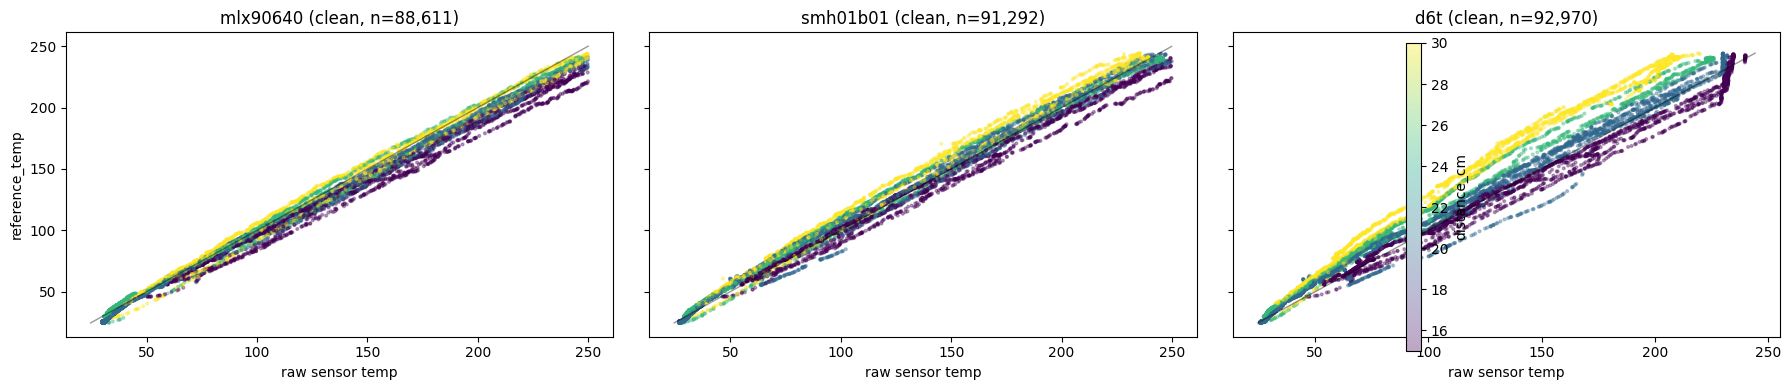

In [91]:

# Quick plots: each sensor uses its own raw/clean training rows.
fig, axes = plt.subplots(1, len(ACTIVE_SENSORS), figsize=(6 * len(ACTIVE_SENSORS), 4), sharey=True)
if len(ACTIVE_SENSORS) == 1: axes = [axes]
sc = None
for ax, (sensor, col) in zip(axes, ACTIVE_SENSORS.items()):
    train_df = TRAIN_DF_BY_SENSOR[sensor]
    plot_df = train_df.sample(min(len(train_df), 12000), random_state=7) if len(train_df) > 12000 else train_df
    sc = ax.scatter(plot_df[col], plot_df['reference_temp'], c=plot_df['distance_cm'], s=4, alpha=0.35, cmap='viridis')
    lo = np.nanmin([plot_df[col].min(), plot_df['reference_temp'].min()]); hi = np.nanmax([plot_df[col].max(), plot_df['reference_temp'].max()])
    ax.plot([lo, hi], [lo, hi], color='black', lw=1, alpha=0.4); ax.set_title(f'{sensor} ({TRAIN_DF_NAME}, n={len(train_df):,})'); ax.set_xlabel('raw sensor temp')
axes[0].set_ylabel('reference_temp')
if sc is not None: fig.colorbar(sc, ax=axes, label='distance_cm')
plt.tight_layout()


In [92]:

# Raw differences against reference, grouped per sensor-specific training data.
for sensor, raw_col in SENSORS.items():
    df_raw[f'diff_{sensor}_raw'] = df_raw[raw_col] - df_raw['reference_temp']
    if sensor in CLEAN_DF_BY_SENSOR: CLEAN_DF_BY_SENSOR[sensor][f'diff_{sensor}_raw'] = CLEAN_DF_BY_SENSOR[sensor][raw_col] - CLEAN_DF_BY_SENSOR[sensor]['reference_temp']
summary_frames = []
for sensor, raw_col in ACTIVE_SENSORS.items():
    train_df = TRAIN_DF_BY_SENSOR[sensor].copy(); diff_col = f'diff_{sensor}_raw'; train_df[diff_col] = train_df[raw_col] - train_df['reference_temp']
    summary = train_df.groupby(['distance_cm', 'direction'])[diff_col].agg(['mean', 'std', 'min', 'max']).reset_index()
    summary.insert(0, 'sensor', sensor); summary_frames.append(summary)
display(pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame())


,sensor,distance_cm,direction,mean,std,min,max
0,mlx90640,15,down,5.023604,2.557622,0.78,15.78
1,mlx90640,15,mixed,11.590801,5.193560,1.30,24.36
2,mlx90640,15,up,21.214646,5.834316,4.10,31.55
3,mlx90640,20,down,3.124586,2.209031,-2.01,9.56
4,mlx90640,20,mixed,5.728445,4.366514,-3.10,17.16
5,mlx90640,20,up,7.841891,2.758235,-1.72,11.59
6,mlx90640,25,down,-1.234436,1.907691,-6.28,5.04
7,mlx90640,25,mixed,2.619540,3.882770,-1.09,11.01
8,mlx90640,25,up,6.505710,1.751293,2.54,10.98
9,mlx90640,30,down,-2.720428,2.464391,-9.14,7.00


## Before / After Cleaning Plots


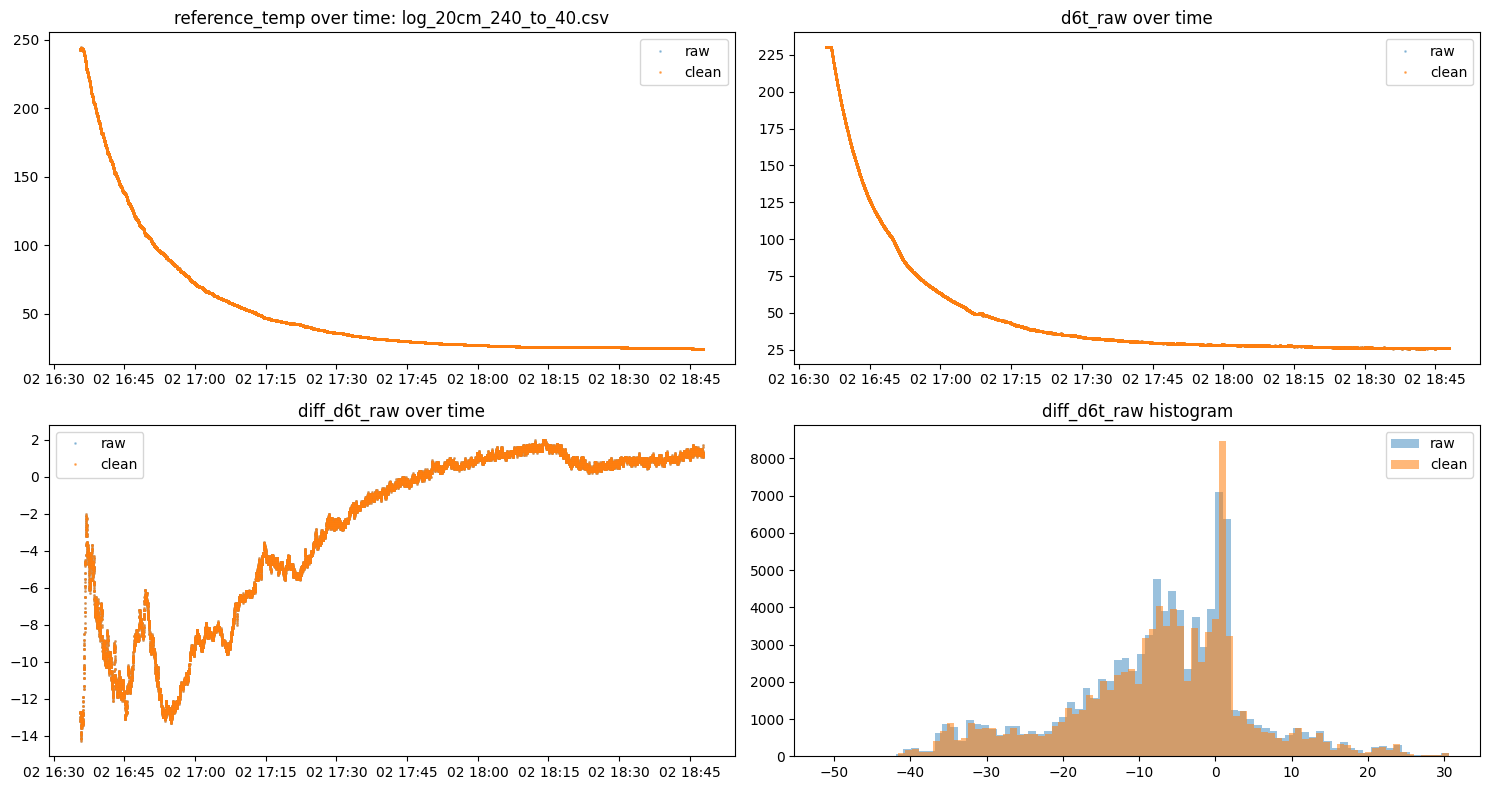

In [93]:

plot_sensor = 'd6t' if 'd6t' in ACTIVE_SENSORS else next(iter(ACTIVE_SENSORS))
plot_col = ACTIVE_SENSORS[plot_sensor]
plot_source = df_raw['source_path'].value_counts().idxmax()
before = df_raw[df_raw['source_path'].eq(plot_source)].sort_values(['timestamp_parsed', 'timestamp'])
after = CLEAN_DF_BY_SENSOR[plot_sensor][CLEAN_DF_BY_SENSOR[plot_sensor]['source_path'].eq(plot_source)].sort_values(['timestamp_parsed', 'timestamp'])
diff_col = f'diff_{plot_sensor}_raw'
fig, axes = plt.subplots(2, 2, figsize=(15, 8)); axes = axes.ravel()
axes[0].plot(before['timestamp_parsed'], before['reference_temp'], '.', ms=2, alpha=0.35, label='raw'); axes[0].plot(after['timestamp_parsed'], after['reference_temp'], '.', ms=2, alpha=0.55, label='clean'); axes[0].set_title(f'reference_temp over time: {plot_source}'); axes[0].legend()
axes[1].plot(before['timestamp_parsed'], before[plot_col], '.', ms=2, alpha=0.35, label='raw'); axes[1].plot(after['timestamp_parsed'], after[plot_col], '.', ms=2, alpha=0.55, label='clean'); axes[1].set_title(f'{plot_col} over time'); axes[1].legend()
axes[2].plot(before['timestamp_parsed'], before[diff_col], '.', ms=2, alpha=0.35, label='raw'); axes[2].plot(after['timestamp_parsed'], after[diff_col], '.', ms=2, alpha=0.55, label='clean'); axes[2].set_title(f'{diff_col} over time'); axes[2].legend()
axes[3].hist(df_raw[diff_col].dropna(), bins=80, alpha=0.45, label='raw'); axes[3].hist(CLEAN_DF_BY_SENSOR[plot_sensor][diff_col].dropna(), bins=80, alpha=0.55, label='clean'); axes[3].set_title(f'{diff_col} histogram'); axes[3].legend(); plt.tight_layout()


In [94]:

# Sensor/distance coverage report. Distance can leak temperature if each distance was sampled over a different range.
def sensor_distance_distribution(sensor: str, raw_col: str, data: pd.DataFrame) -> pd.DataFrame:
    usable = data.dropna(subset=['reference_temp', raw_col, 'distance_cm']).copy()
    usable = usable[np.isfinite(usable[['reference_temp', raw_col, 'distance_cm']]).all(axis=1)]
    report = usable.groupby('distance_cm').agg(
        rows=(raw_col, 'size'),
        raw_min=(raw_col, 'min'),
        raw_max=(raw_col, 'max'),
        reference_min=('reference_temp', 'min'),
        reference_max=('reference_temp', 'max'),
    ).reset_index()
    report.insert(0, 'sensor', sensor)
    return report

distribution_frames = []
for sensor, raw_col in ACTIVE_SENSORS.items():
    distribution_frames.append(sensor_distance_distribution(sensor, raw_col, TRAIN_DF_BY_SENSOR[sensor]))
sensor_distance_report = pd.concat(distribution_frames, ignore_index=True) if distribution_frames else pd.DataFrame()
sensor_distance_report.to_csv(REPORTS_DIR / 'sensor_distance_distribution.csv', index=False)
display(sensor_distance_report)

for sensor, group in sensor_distance_report.groupby('sensor'):
    ref_span_min = float(group['reference_min'].min()) if len(group) else np.nan
    ref_span_max = float(group['reference_max'].max()) if len(group) else np.nan
    full_span = ref_span_max - ref_span_min
    narrow = group[(group['reference_max'] - group['reference_min']).lt(max(20.0, full_span * 0.35))]
    if len(group) > 1 and len(narrow):
        print(
            f"[WARN] unbalanced temperature range across distances; distance feature may cause leakage/overfit. "
            f"sensor={sensor} full_reference_range={ref_span_min:.1f}..{ref_span_max:.1f} narrow_distances="
            f"{narrow[['distance_cm', 'reference_min', 'reference_max', 'rows']].to_dict('records')}"
        )


,sensor,distance_cm,rows,raw_min,raw_max,reference_min,reference_max
0,mlx90640,15,16595,50.11,249.95,46.0,234.2
1,mlx90640,20,34568,29.70,249.97,24.6,242.0
2,mlx90640,25,18830,30.68,247.40,24.6,241.0
3,mlx90640,30,18618,33.55,249.99,29.1,243.8
4,smh01b01,15,16953,46.30,250.00,46.0,240.3
5,smh01b01,20,35736,26.80,249.80,24.6,244.4
6,smh01b01,25,19893,27.30,246.00,24.6,241.0
7,smh01b01,30,18710,29.40,239.30,29.1,244.2
8,d6t,15,18024,46.10,240.00,46.0,243.4
9,d6t,20,36361,25.60,232.00,24.6,244.4


In [95]:

MODEL_SPECS = [('linear_raw', 1, ['raw']), ('poly2_raw', 2, ['raw']), ('poly3_raw', 3, ['raw']), ('poly2_raw_distance', 2, ['raw', 'distance_cm']), ('poly3_raw_distance', 3, ['raw', 'distance_cm'])]

def model_specs_for_sensor(sensor: str) -> list[tuple[str, int, list[str]]]:
    specs = []
    for name, degree, features in MODEL_SPECS:
        if sensor in DISABLE_DISTANCE_FOR_SENSORS and 'distance_cm' in features:
            continue
        specs.append((name, degree, features))
    return specs

def feature_frame(data: pd.DataFrame, raw_col: str, features: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=data.index)
    for feature in features: out[feature] = data[raw_col] if feature == 'raw' else data[feature]
    return out

def deterministic_holdout(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    order = data.groupby('source_path').cumcount(); test_mask = order.mod(5).eq(0)
    return data.loc[~test_mask].copy(), data.loc[test_mask].copy()

def model_input_data(data: pd.DataFrame, raw_col: str, features: list[str]) -> pd.DataFrame:
    needed = ['reference_temp', raw_col, 'source_path'] + [f for f in features if f != 'raw']
    out = data.dropna(subset=list(dict.fromkeys(needed))).copy(); numeric_needed = ['reference_temp', raw_col] + [f for f in features if f != 'raw']
    return out[np.isfinite(out[numeric_needed]).all(axis=1)]

def fit_pipeline(train: pd.DataFrame, raw_col: str, degree: int, features: list[str]) -> Pipeline:
    model = Pipeline([('poly', PolynomialFeatures(degree=degree, include_bias=True)), ('linear', LinearRegression(fit_intercept=False))])
    model.fit(feature_frame(train, raw_col, features), train['reference_temp']); return model

def evaluate_model_on(data: pd.DataFrame, sensor: str, raw_col: str, name: str, degree: int, features: list[str], label: str) -> tuple[dict, Pipeline]:
    usable = model_input_data(data, raw_col, features); train, test = deterministic_holdout(usable)
    if len(train) == 0 or len(test) == 0: raise RuntimeError(f'Not enough rows to evaluate {sensor}/{name} on {label}')
    model = fit_pipeline(train, raw_col, degree, features); pred = model.predict(feature_frame(test, raw_col, features))
    eval_df = test[['reference_temp', 'distance_cm', 'direction']].copy(); eval_df['pred'] = pred; eval_df['raw'] = test[raw_col].to_numpy()
    eval_df['raw_abs_error'] = (eval_df['raw'] - eval_df['reference_temp']).abs()
    eval_df['calib_abs_error'] = (eval_df['pred'] - eval_df['reference_temp']).abs()
    denom = eval_df['reference_temp'].abs().replace(0, np.nan)
    eval_df['calib_abs_pct_of_gdm'] = eval_df['calib_abs_error'] / denom * 100.0
    raw_mae = float(eval_df['raw_abs_error'].mean())
    calib_mae = float(eval_df['calib_abs_error'].mean())
    mean_abs_pct = float(eval_df['calib_abs_pct_of_gdm'].mean())
    pass_improves_raw = bool(calib_mae < raw_mae)
    pass_under_pct = bool(mean_abs_pct < MAX_MEAN_ABS_PERCENT_OF_GDM)
    by_distance = {int(distance): float(mean_absolute_error(group['reference_temp'], group['pred'])) for distance, group in eval_df.groupby('distance_cm')}
    pct_by_distance = {int(distance): float(group['calib_abs_pct_of_gdm'].mean()) for distance, group in eval_df.groupby('distance_cm')}
    raw_mae_by_distance = {int(distance): float(group['raw_abs_error'].mean()) for distance, group in eval_df.groupby('distance_cm')}
    row = {'dataset': label, 'sensor': sensor, 'model': name, 'degree': degree, 'features': features, 'MAE': calib_mae, 'RMSE': float(np.sqrt(mean_squared_error(test['reference_temp'], pred))), 'R2': float(r2_score(test['reference_temp'], pred)), 'MAE_raw': raw_mae, 'MAE_improvement': raw_mae - calib_mae, 'mean_abs_pct_of_gdm': mean_abs_pct, 'pass_improves_raw': pass_improves_raw, 'pass_under_5pct_gdm': pass_under_pct, 'pass_training_goal': bool(pass_improves_raw or pass_under_pct), 'MAE_by_distance': by_distance, 'raw_MAE_by_distance': raw_mae_by_distance, 'pct_error_by_distance': pct_by_distance, 'distance_mae_span': float(max(by_distance.values()) - min(by_distance.values())) if by_distance else np.nan, 'n_coefficients': int(len(model.named_steps['linear'].coef_)), 'rows': int(len(usable))}
    for direction in ['up', 'down', 'mixed']:
        subset = eval_df[eval_df['direction'].eq(direction)]; row[f'MAE_{direction}'] = float(mean_absolute_error(subset['reference_temp'], subset['pred'])) if len(subset) else np.nan
    goal_penalty = 0.0 if row['pass_training_goal'] else 1000.0
    row['selection_score'] = goal_penalty + row['RMSE'] + 0.10 * row['distance_mae_span'] + 0.002 * row['n_coefficients']; return row, model

rows=[]
for sensor, raw_col in ACTIVE_SENSORS.items():
    datasets = [('raw', df_raw), ('clean', CLEAN_DF_BY_SENSOR[sensor])]
    for dataset_label, dataset in datasets:
        for name, degree, features in model_specs_for_sensor(sensor):
            rows.append(evaluate_model_on(dataset, sensor, raw_col, name, degree, features, dataset_label)[0])
all_results = pd.DataFrame(rows).sort_values(['dataset', 'sensor', 'selection_score']); results = all_results[all_results['dataset'].eq(TRAIN_DF_NAME)].copy()
metric_compare = all_results.pivot_table(index=['sensor', 'model'], columns='dataset', values=['MAE', 'RMSE', 'rows'], aggfunc='first').reset_index()
metric_compare.columns = ['_'.join([str(x) for x in col if x]).rstrip('_') for col in metric_compare.columns.to_flat_index()]
metric_compare = metric_compare.rename(columns={'MAE_raw': 'MAE_raw_train', 'RMSE_raw': 'RMSE_raw_train', 'MAE_clean': 'MAE_clean_train', 'RMSE_clean': 'RMSE_clean_train', 'rows_raw': 'rows_raw_train', 'rows_clean': 'rows_clean_train'})
metric_compare = metric_compare.merge(cleaning_stats[['sensor', 'rows_raw', 'rows_clean', 'rows_removed', 'rows_skipped_missing_sensor']], on='sensor', how='left')
metric_compare = metric_compare.sort_values(['sensor', 'MAE_clean_train', 'RMSE_clean_train'])
display(all_results[['dataset', 'sensor', 'model', 'MAE_raw', 'MAE', 'MAE_improvement', 'mean_abs_pct_of_gdm', 'pass_improves_raw', 'pass_under_5pct_gdm', 'pass_training_goal', 'RMSE', 'R2', 'MAE_up', 'MAE_down', 'MAE_mixed', 'MAE_by_distance', 'raw_MAE_by_distance', 'pct_error_by_distance', 'distance_mae_span', 'n_coefficients', 'rows', 'selection_score']])
display(metric_compare[['sensor', 'model', 'MAE_raw_train', 'RMSE_raw_train', 'MAE_clean_train', 'RMSE_clean_train', 'rows_raw_train', 'rows_clean_train', 'rows_removed', 'rows_skipped_missing_sensor']])


,dataset,sensor,model,MAE_raw,MAE,MAE_improvement,mean_abs_pct_of_gdm,pass_improves_raw,pass_under_5pct_gdm,pass_training_goal,...,MAE_up,MAE_down,MAE_mixed,MAE_by_distance,raw_MAE_by_distance,pct_error_by_distance,distance_mae_span,n_coefficients,rows,selection_score
28,clean,d6t,poly2_raw_distance,10.363172,3.874509,6.488663,4.403696,True,True,True,...,6.519257,2.794613,4.585639,"{15: 5.317996077204931, 20: 3.541808117006491,...","{15: 6.475346644481419, 20: 4.988314544954633,...","{15: 4.049506158971812, 20: 5.142259553759068,...",2.178009,6,92970,5.926231
29,clean,d6t,poly3_raw_distance,10.363172,3.967242,6.395930,4.465526,True,True,True,...,5.816877,2.728418,5.088320,"{15: 6.9344233494445895, 20: 3.58546211317463,...","{15: 6.475346644481419, 20: 4.988314544954633,...","{15: 5.881860992211156, 20: 5.3621082051652245...",4.561554,10,92970,6.342155
27,clean,d6t,poly3_raw,10.363172,8.411501,1.951671,8.835150,True,False,True,...,12.819118,5.601939,10.899176,"{15: 13.496465918536146, 20: 4.662950696425442...","{15: 6.475346644481419, 20: 4.988314544954633,...","{15: 10.794445168435026, 20: 8.744126080618674...",9.306736,4,92970,12.277847
26,clean,d6t,poly2_raw,10.363172,8.257746,2.105426,8.213249,True,False,True,...,12.777097,5.288983,10.921958,"{15: 13.686873230418831, 20: 4.180880555020725...","{15: 6.475346644481419, 20: 4.988314544954633,...","{15: 11.03532496500004, 20: 6.893682630022227,...",9.740833,3,92970,12.279109
25,clean,d6t,linear_raw,10.363172,8.986892,1.376280,10.358069,True,False,True,...,13.553253,6.629467,10.850470,"{15: 12.712478420354243, 20: 5.385062347155785...","{15: 6.475346644481419, 20: 4.988314544954633,...","{15: 9.48623398328776, 20: 12.173950133196447,...",9.878045,2,92970,12.876320
8,clean,mlx90640,poly2_raw_distance,5.008417,2.894126,2.114291,3.641797,True,True,True,...,5.201980,2.453871,2.916142,"{15: 4.231741918873708, 20: 2.2272042357589585...","{15: 10.768033132530121, 20: 4.275384726641596...","{15: 3.712811707662952, 20: 4.034306768440923,...",2.004538,6,88611,3.948707
9,clean,mlx90640,poly3_raw_distance,5.008417,3.733073,1.275345,4.546935,True,True,True,...,5.872388,3.002115,4.209575,"{15: 6.192782788717029, 20: 3.034636467046645,...","{15: 10.768033132530121, 20: 4.275384726641596...","{15: 5.6286591459165916, 20: 5.128823502210904...",3.374849,10,88611,5.251551
7,clean,mlx90640,poly3_raw,5.008417,3.887824,1.120593,5.221028,True,False,True,...,5.548335,3.346667,4.220663,"{15: 5.6070132723259185, 20: 2.752739646811692...","{15: 10.768033132530121, 20: 4.275384726641596...","{15: 4.4560025905817975, 20: 6.338055081199986...",2.854274,4,88611,5.376765
6,clean,mlx90640,poly2_raw,5.008417,3.819578,1.188840,4.834084,True,True,True,...,5.713193,3.169914,4.245106,"{15: 5.76183183608106, 20: 2.4036117875317333,...","{15: 10.768033132530121, 20: 4.275384726641596...","{15: 4.6078793663085005, 20: 5.00036061642279,...",3.358220,3,88611,5.381504
5,clean,mlx90640,linear_raw,5.008417,3.930663,1.077754,5.288313,True,False,True,...,5.261700,3.470528,4.234688,"{15: 5.504404927343185, 20: 2.8138811937751513...","{15: 10.768033132530121, 20: 4.275384726641596...","{15: 4.249864669451902, 20: 6.404467419617853,...",2.690524,2,88611,5.396120


,sensor,model,MAE_raw_train,RMSE_raw_train,MAE_clean_train,RMSE_clean_train,rows_raw_train,rows_clean_train,rows_removed,rows_skipped_missing_sensor
2,d6t,poly2_raw_distance,3.883440,5.714239,3.874509,5.696430,93021,92970,51,0
4,d6t,poly3_raw_distance,3.973826,5.889333,3.967242,5.865999,93021,92970,51,0
1,d6t,poly2_raw,8.264446,11.310616,8.257746,11.299025,93021,92970,51,0
3,d6t,poly3_raw,8.417185,11.350136,8.411501,11.339173,93021,92970,51,0
0,d6t,linear_raw,8.993218,11.894553,8.986892,11.884515,93021,92970,51,0
7,mlx90640,poly2_raw_distance,3.431500,5.026290,2.894126,3.736253,93021,88611,4410,0
9,mlx90640,poly3_raw_distance,4.166387,6.072451,3.733073,4.894066,93021,88611,4410,0
6,mlx90640,poly2_raw,4.297800,6.121535,3.819578,5.039682,93021,88611,4410,0
8,mlx90640,poly3_raw,4.373962,6.139747,3.887824,5.083338,93021,88611,4410,0
5,mlx90640,linear_raw,4.487501,6.221977,3.930663,5.123068,93021,88611,4410,0


In [96]:

def choose_best(group: pd.DataFrame) -> pd.Series:
    best_rmse = group['RMSE'].min(); close = group[group['RMSE'].le(best_rmse * 1.02 + 0.05)].copy()
    return close.sort_values(['n_coefficients', 'selection_score']).iloc[0]

selected_rows=[]
for sensor_name, group in results.groupby('sensor'):
    row = choose_best(group).copy(); row['sensor'] = sensor_name; selected_rows.append(row)
selected = pd.DataFrame(selected_rows).reset_index(drop=True)


def profile_from_fit(data: pd.DataFrame, raw_col: str, model_name: str, degree: int, features: list[str]) -> dict:
    usable = model_input_data(data, raw_col, features)
    model = fit_pipeline(usable, raw_col, degree, features)
    poly = model.named_steps['poly']; linear = model.named_steps['linear']
    return {
        'model_name': model_name,
        'degree': int(degree),
        'features': features,
        'feature_names_in': features,
        'powers': poly.powers_.astype(int).tolist(),
        'coefficients': [float(x) for x in linear.coef_],
        'target_mode': 'predict_absolute',
        'uses_direction': False,
    }

def predict_exported_profile(profile: dict, data: pd.DataFrame, raw_col: str) -> np.ndarray:
    values = []
    for feature in profile['features']:
        values.append(data[raw_col].to_numpy(dtype=float) if feature == 'raw' else data[feature].to_numpy(dtype=float))
    pred = np.zeros(len(data), dtype=float)
    for coefficient, powers in zip(profile['coefficients'], profile['powers']):
        term = np.full(len(data), float(coefficient), dtype=float)
        for value, power in zip(values, powers):
            if power:
                term *= value ** int(power)
        pred += term
    return pred

def predict_per_distance_profile(profile: dict, data: pd.DataFrame, raw_col: str) -> np.ndarray:
    pred = np.full(len(data), np.nan, dtype=float)
    distance_profiles = profile['per_distance_profiles']
    available = sorted((float(k), k) for k in distance_profiles)
    for distance, idx in data.groupby('distance_cm').groups.items():
        requested = float(distance)
        exact_key = str(int(requested))
        subset = data.loc[idx]
        if exact_key in distance_profiles:
            pred[data.index.get_indexer(idx)] = predict_exported_profile(distance_profiles[exact_key], subset, raw_col)
            continue
        lower = [item for item in available if item[0] <= requested]
        upper = [item for item in available if item[0] >= requested]
        if lower and upper and lower[-1][1] != upper[0][1]:
            lo_value, lo_key = lower[-1]; hi_value, hi_key = upper[0]
            lo_pred = predict_exported_profile(distance_profiles[lo_key], subset, raw_col)
            hi_pred = predict_exported_profile(distance_profiles[hi_key], subset, raw_col)
            ratio = (requested - lo_value) / (hi_value - lo_value)
            pred[data.index.get_indexer(idx)] = lo_pred + ratio * (hi_pred - lo_pred)
        else:
            nearest_key = min(available, key=lambda item: abs(item[0] - requested))[1]
            pred[data.index.get_indexer(idx)] = predict_exported_profile(distance_profiles[nearest_key], subset, raw_col)
    return pred

def build_per_distance_profile(sensor: str, raw_col: str) -> tuple[dict, pd.Series]:
    data = model_input_data(TRAIN_DF_BY_SENSOR[sensor], raw_col, ['raw', 'distance_cm'])
    per_distance_profiles = {}
    holdout_frames = []
    distance_metrics = {}
    for distance, group in data.groupby('distance_cm'):
        candidates = []
        for name, degree, features in [spec for spec in model_specs_for_sensor(sensor) if 'distance_cm' not in spec[2]]:
            try:
                metric, _ = evaluate_model_on(group, sensor, raw_col, name, degree, features, TRAIN_DF_NAME)
                candidates.append(metric)
            except RuntimeError:
                continue
        if not candidates:
            continue
        best = choose_best(pd.DataFrame(candidates))
        per_distance_profiles[str(int(distance))] = profile_from_fit(group, raw_col, best['model'], int(best['degree']), list(best['features']))
        distance_metrics[str(int(distance))] = {
            'model_name': best['model'],
            'MAE_raw': float(best['MAE_raw']),
            'MAE': float(best['MAE']),
            'MAE_improvement': float(best['MAE_improvement']),
            'mean_abs_pct_of_gdm': float(best['mean_abs_pct_of_gdm']),
            'pass_training_goal': bool(best['pass_training_goal']),
            'rows': int(best['rows']),
        }
        train, test = deterministic_holdout(model_input_data(group, raw_col, list(best['features'])))
        model = fit_pipeline(train, raw_col, int(best['degree']), list(best['features']))
        pred = model.predict(feature_frame(test, raw_col, list(best['features'])))
        eval_df = test[['reference_temp', 'distance_cm', 'direction']].copy()
        eval_df['raw'] = test[raw_col].to_numpy(dtype=float)
        eval_df['pred'] = pred
        holdout_frames.append(eval_df)
    if not per_distance_profiles or not holdout_frames:
        raise RuntimeError(f'No per-distance model could be trained for {sensor}')
    eval_all = pd.concat(holdout_frames, ignore_index=True)
    eval_all['raw_abs_error'] = (eval_all['raw'] - eval_all['reference_temp']).abs()
    eval_all['calib_abs_error'] = (eval_all['pred'] - eval_all['reference_temp']).abs()
    eval_all['calib_abs_pct_of_gdm'] = eval_all['calib_abs_error'] / eval_all['reference_temp'].abs().replace(0, np.nan) * 100.0
    raw_mae = float(eval_all['raw_abs_error'].mean())
    calib_mae = float(eval_all['calib_abs_error'].mean())
    mean_pct = float(eval_all['calib_abs_pct_of_gdm'].mean())
    by_distance = {int(distance): float(group['calib_abs_error'].mean()) for distance, group in eval_all.groupby('distance_cm')}
    raw_by_distance = {int(distance): float(group['raw_abs_error'].mean()) for distance, group in eval_all.groupby('distance_cm')}
    pct_by_distance = {int(distance): float(group['calib_abs_pct_of_gdm'].mean()) for distance, group in eval_all.groupby('distance_cm')}
    profile = {
        'model_name': 'per_distance_raw',
        'features': ['raw'],
        'feature_names_in': ['raw'],
        'target_mode': 'predict_absolute',
        'uses_direction': False,
        'per_distance_profiles': per_distance_profiles,
        'distance_metrics': distance_metrics,
        'fallback_profile': profile_from_fit(data, raw_col, 'poly2_raw', 2, ['raw']),
    }
    selected_row = pd.Series({
        'dataset': TRAIN_DF_NAME,
        'sensor': sensor,
        'model': 'per_distance_raw',
        'degree': 0,
        'features': ['raw'],
        'MAE_raw': raw_mae,
        'MAE': calib_mae,
        'MAE_improvement': raw_mae - calib_mae,
        'mean_abs_pct_of_gdm': mean_pct,
        'pass_improves_raw': bool(calib_mae < raw_mae),
        'pass_under_5pct_gdm': bool(mean_pct < MAX_MEAN_ABS_PERCENT_OF_GDM),
        'pass_training_goal': bool((calib_mae < raw_mae) or (mean_pct < MAX_MEAN_ABS_PERCENT_OF_GDM)),
        'RMSE': float(np.sqrt((eval_all['calib_abs_error'] ** 2).mean())),
        'R2': float(r2_score(eval_all['reference_temp'], eval_all['pred'])),
        'MAE_by_distance': by_distance,
        'raw_MAE_by_distance': raw_by_distance,
        'pct_error_by_distance': pct_by_distance,
        'distance_mae_span': float(max(by_distance.values()) - min(by_distance.values())) if by_distance else np.nan,
        'n_coefficients': int(sum(len(p['coefficients']) for p in per_distance_profiles.values())),
        'rows': int(len(data)),
    })
    return profile, selected_row

PER_DISTANCE_EXPORT_PROFILES = {}
for sensor in PER_DISTANCE_MODEL_SENSORS:
    if sensor in ACTIVE_SENSORS:
        profile, per_distance_row = build_per_distance_profile(sensor, SENSORS[sensor])
        PER_DISTANCE_EXPORT_PROFILES[sensor] = profile
        selected = selected[selected['sensor'].ne(sensor)]
        selected = pd.concat([selected, per_distance_row.to_frame().T], ignore_index=True)
selected = selected.sort_values('sensor').reset_index(drop=True)

display(selected[['sensor', 'model', 'features', 'MAE_raw', 'MAE', 'MAE_improvement', 'mean_abs_pct_of_gdm', 'pass_improves_raw', 'pass_under_5pct_gdm', 'pass_training_goal', 'RMSE', 'R2', 'MAE_by_distance', 'raw_MAE_by_distance', 'pct_error_by_distance', 'rows']])
acceptance_report = selected[['sensor', 'model', 'features', 'MAE_raw', 'MAE', 'MAE_improvement', 'mean_abs_pct_of_gdm', 'pass_improves_raw', 'pass_under_5pct_gdm', 'pass_training_goal']].copy()
acceptance_report.to_csv(REPORTS_DIR / 'calibration_acceptance_report.csv', index=False)
for _, row in acceptance_report.iterrows():
    status = 'PASS' if bool(row['pass_training_goal']) else 'WARN'
    print(f"[{status}] calibration goal sensor={row['sensor']} model={row['model']} raw_MAE={row['MAE_raw']:.3f} calib_MAE={row['MAE']:.3f} improvement={row['MAE_improvement']:.3f} mean_abs_pct_of_gdm={row['mean_abs_pct_of_gdm']:.2f}%")

# Acceptance detail by distance and direction. This checks distance-dependent error without forcing distance_cm into the model.
acceptance_detail_rows = []
for _, row in selected.iterrows():
    sensor = row['sensor']; raw_col = SENSORS[sensor]; features = list(row['features'])
    data = model_input_data(TRAIN_DF_BY_SENSOR[sensor], raw_col, features)
    if sensor in PER_DISTANCE_EXPORT_PROFILES:
        pred = predict_per_distance_profile(PER_DISTANCE_EXPORT_PROFILES[sensor], data, raw_col)
    else:
        model = fit_pipeline(data, raw_col, int(row['degree']), features)
        pred = model.predict(feature_frame(data, raw_col, features))
    eval_df = data[['reference_temp', 'distance_cm', 'direction']].copy()
    eval_df['raw'] = data[raw_col].to_numpy(); eval_df['calib'] = pred
    eval_df['raw_abs_error'] = (eval_df['raw'] - eval_df['reference_temp']).abs()
    eval_df['calib_abs_error'] = (eval_df['calib'] - eval_df['reference_temp']).abs()
    eval_df['calib_abs_pct_of_gdm'] = eval_df['calib_abs_error'] / eval_df['reference_temp'].abs().replace(0, np.nan) * 100.0
    for (distance, direction), group in eval_df.groupby(['distance_cm', 'direction']):
        raw_mae = float(group['raw_abs_error'].mean())
        calib_mae = float(group['calib_abs_error'].mean())
        pct = float(group['calib_abs_pct_of_gdm'].mean())
        acceptance_detail_rows.append({
            'sensor': sensor,
            'model': row['model'],
            'features': features,
            'distance_cm': int(distance),
            'direction': direction,
            'rows': int(len(group)),
            'MAE_raw': raw_mae,
            'MAE_calib': calib_mae,
            'MAE_improvement': raw_mae - calib_mae,
            'mean_abs_pct_of_gdm': pct,
            'pass_improves_raw': bool(calib_mae < raw_mae),
            'pass_under_5pct_gdm': bool(pct < MAX_MEAN_ABS_PERCENT_OF_GDM),
            'pass_training_goal': bool((calib_mae < raw_mae) or (pct < MAX_MEAN_ABS_PERCENT_OF_GDM)),
        })
acceptance_detail = pd.DataFrame(acceptance_detail_rows)
acceptance_detail.to_csv(REPORTS_DIR / 'calibration_acceptance_by_distance.csv', index=False)
display(acceptance_detail)
for _, row in acceptance_detail[~acceptance_detail['pass_training_goal']].iterrows():
    print(f"[WARN] calibration goal failed by distance sensor={row['sensor']} distance={row['distance_cm']} direction={row['direction']} raw_MAE={row['MAE_raw']:.3f} calib_MAE={row['MAE_calib']:.3f} mean_abs_pct_of_gdm={row['mean_abs_pct_of_gdm']:.2f}%")

if 'd6t' in selected['sensor'].values and 'd6t_calib_old' in df_raw.columns:
    d6t_train_df = TRAIN_DF_BY_SENSOR['d6t']
    d6t_compare_base = d6t_train_df.dropna(subset=['reference_temp', 'd6t_raw', 'distance_cm']).copy()
    d6t_compare_base = d6t_compare_base[np.isfinite(d6t_compare_base[['reference_temp', 'd6t_raw', 'distance_cm']]).all(axis=1)]
    old_rows = d6t_compare_base.dropna(subset=['d6t_calib_old'])
    selected_d6t = selected[selected['sensor'].eq('d6t')].iloc[0]
    if 'd6t' in PER_DISTANCE_EXPORT_PROFILES:
        d6t_compare_base['new_calib'] = predict_per_distance_profile(PER_DISTANCE_EXPORT_PROFILES['d6t'], d6t_compare_base, 'd6t_raw')
    else:
        new_model = fit_pipeline(model_input_data(d6t_train_df, 'd6t_raw', list(selected_d6t['features'])), 'd6t_raw', int(selected_d6t['degree']), list(selected_d6t['features']))
        d6t_compare_base['new_calib'] = new_model.predict(feature_frame(d6t_compare_base, 'd6t_raw', list(selected_d6t['features'])))
    d6t_rows_removed = int(cleaning_stats.loc[cleaning_stats['sensor'].eq('d6t'), 'rows_removed'].iloc[0])
    d6t_refit_summary = pd.DataFrame([{'rows_train': int(len(d6t_compare_base)), 'rows_removed': d6t_rows_removed, 'MAE_raw': float(mean_absolute_error(d6t_compare_base['reference_temp'], d6t_compare_base['d6t_raw'])), 'MAE_old_calib': float(mean_absolute_error(old_rows['reference_temp'], old_rows['d6t_calib_old'])) if len(old_rows) else np.nan, 'MAE_new_calib': float(mean_absolute_error(d6t_compare_base['reference_temp'], d6t_compare_base['new_calib'])), 'mean_abs_pct_of_gdm_new_calib': float(((d6t_compare_base['new_calib'] - d6t_compare_base['reference_temp']).abs() / d6t_compare_base['reference_temp'].abs().replace(0, np.nan) * 100.0).mean()), 'model_d6t_selected': selected_d6t['model'], 'd6t_report_files_loaded': report_file_count}])
    display(d6t_refit_summary)


,sensor,model,features,MAE_raw,MAE,MAE_improvement,mean_abs_pct_of_gdm,pass_improves_raw,pass_under_5pct_gdm,pass_training_goal,RMSE,R2,MAE_by_distance,raw_MAE_by_distance,pct_error_by_distance,rows
0,d6t,poly2_raw_distance,"[raw, distance_cm]",10.363172,3.874509,6.488663,4.403696,True,True,True,5.696430,0.992658,"{15: 5.317996077204931, 20: 3.541808117006491,...","{15: 6.475346644481419, 20: 4.988314544954633,...","{15: 4.049506158971812, 20: 5.142259553759068,...",92970
1,mlx90640,poly2_raw_distance,"[raw, distance_cm]",5.008417,2.894126,2.114291,3.641797,True,True,True,3.736253,0.996614,"{15: 4.231741918873708, 20: 2.2272042357589585...","{15: 10.768033132530121, 20: 4.275384726641596...","{15: 3.712811707662952, 20: 4.034306768440923,...",88611
2,smh01b01,poly2_raw_distance,"[raw, distance_cm]",5.359823,3.213095,2.146728,3.688043,True,True,True,4.293922,0.995710,"{15: 4.237887735625721, 20: 3.0991761690641972...","{15: 5.873378537735849, 20: 3.941502308015107,...","{15: 3.627898842175721, 20: 4.664427903371456,...",91292


[PASS] calibration goal sensor=d6t model=poly2_raw_distance raw_MAE=10.363 calib_MAE=3.875 improvement=6.489 mean_abs_pct_of_gdm=4.40%
[PASS] calibration goal sensor=mlx90640 model=poly2_raw_distance raw_MAE=5.008 calib_MAE=2.894 improvement=2.114 mean_abs_pct_of_gdm=3.64%
[PASS] calibration goal sensor=smh01b01 model=poly2_raw_distance raw_MAE=5.360 calib_MAE=3.213 improvement=2.147 mean_abs_pct_of_gdm=3.69%


,sensor,model,features,distance_cm,direction,rows,MAE_raw,MAE_calib,MAE_improvement,mean_abs_pct_of_gdm,pass_improves_raw,pass_under_5pct_gdm,pass_training_goal
0,d6t,poly2_raw_distance,"[raw, distance_cm]",15,down,4865,2.718109,3.653649,-0.935540,3.444574,False,True,True
1,d6t,poly2_raw_distance,"[raw, distance_cm]",15,mixed,10827,6.498107,4.904767,1.593340,3.693958,True,True,True
2,d6t,poly2_raw_distance,"[raw, distance_cm]",15,up,2332,14.210334,10.699802,3.510532,6.963378,True,False,True
3,d6t,poly2_raw_distance,"[raw, distance_cm]",20,down,22463,3.727071,2.329335,1.397736,5.097256,True,False,True
4,d6t,poly2_raw_distance,"[raw, distance_cm]",20,mixed,12051,7.670301,5.625984,2.044318,5.580462,True,False,True
5,d6t,poly2_raw_distance,"[raw, distance_cm]",20,up,1847,2.883216,4.716911,-1.833695,2.932600,False,True,True
6,d6t,poly2_raw_distance,"[raw, distance_cm]",25,down,11857,10.931652,2.406363,8.525289,3.048195,True,True,True
7,d6t,poly2_raw_distance,"[raw, distance_cm]",25,mixed,5193,14.793588,4.625091,10.168496,4.212340,True,True,True
8,d6t,poly2_raw_distance,"[raw, distance_cm]",25,up,2843,13.651073,3.479086,10.171987,4.092714,True,True,True
9,d6t,poly2_raw_distance,"[raw, distance_cm]",30,down,7892,19.255765,4.174038,15.081728,5.476147,True,False,True


[WARN] calibration goal failed by distance sensor=smh01b01 distance=25 direction=up raw_MAE=3.120 calib_MAE=6.833 mean_abs_pct_of_gdm=6.75%
[WARN] calibration goal failed by distance sensor=smh01b01 distance=30 direction=up raw_MAE=3.588 calib_MAE=6.085 mean_abs_pct_of_gdm=6.52%


,rows_train,rows_removed,MAE_raw,MAE_old_calib,MAE_new_calib,mean_abs_pct_of_gdm_new_calib,model_d6t_selected,d6t_report_files_loaded
0,92970,51,10.364901,NaN,3.873939,4.403612,poly2_raw_distance,0


In [97]:

# Per-sample calibration result log. PASS if calib beats raw or calib error is under 5% of GDM.
result_rows = []
for _, selected_row in selected.iterrows():
    sensor = selected_row['sensor']
    raw_col = SENSORS[sensor]
    features = list(selected_row['features'])
    data = model_input_data(TRAIN_DF_BY_SENSOR[sensor], raw_col, features)
    if sensor in PER_DISTANCE_EXPORT_PROFILES:
        pred = predict_per_distance_profile(PER_DISTANCE_EXPORT_PROFILES[sensor], data, raw_col)
    else:
        model = fit_pipeline(data, raw_col, int(selected_row['degree']), features)
        pred = model.predict(feature_frame(data, raw_col, features))
    result_df = data[['source_path', 'timestamp', 'distance_cm', 'direction', 'csv_format', 'reference_temp']].copy()
    result_df.insert(0, 'sensor', sensor)
    result_df['model'] = selected_row['model']
    result_df['features'] = ','.join(features)
    result_df['raw'] = data[raw_col].to_numpy(dtype=float)
    result_df['calib'] = pred.astype(float)
    result_df['dif_raw'] = (result_df['raw'] - result_df['reference_temp']).abs()
    result_df['dif_calib'] = (result_df['calib'] - result_df['reference_temp']).abs()
    result_df['dif_calib_pct_gdm'] = result_df['dif_calib'] / result_df['reference_temp'].abs().replace(0, np.nan) * 100.0
    result_df['pass_calib_better_than_raw'] = result_df['dif_calib'].lt(result_df['dif_raw'])
    result_df['pass_calib_under_5pct_gdm'] = result_df['dif_calib_pct_gdm'].lt(MAX_MEAN_ABS_PERCENT_OF_GDM)
    result_df['result'] = np.where(result_df['pass_calib_better_than_raw'] | result_df['pass_calib_under_5pct_gdm'], 'PASS', 'FAIL')
    result_rows.append(result_df)

calibration_result_log = pd.concat(result_rows, ignore_index=True) if result_rows else pd.DataFrame()
calibration_result_log.to_csv(REPORTS_DIR / 'calibration_result_log.csv', index=False)

calibration_result_summary = calibration_result_log.groupby(['sensor', 'model', 'distance_cm', 'direction']).agg(
    rows=('result', 'size'),
    pass_rows=('result', lambda s: int(s.eq('PASS').sum())),
    fail_rows=('result', lambda s: int(s.eq('FAIL').sum())),
    pass_rate_pct=('result', lambda s: float(s.eq('PASS').mean() * 100.0)),
    mean_dif_raw=('dif_raw', 'mean'),
    mean_dif_calib=('dif_calib', 'mean'),
    mean_dif_calib_pct_gdm=('dif_calib_pct_gdm', 'mean'),
).reset_index()
calibration_result_summary.to_csv(REPORTS_DIR / 'calibration_result_summary_by_distance.csv', index=False)

display(calibration_result_summary)
for _, row in calibration_result_summary[calibration_result_summary['fail_rows'].gt(0)].iterrows():
    print(
        f"[RESULT] sensor={row['sensor']} distance={int(row['distance_cm'])} direction={row['direction']} "
        f"pass_rate={row['pass_rate_pct']:.1f}% pass={int(row['pass_rows'])}/{int(row['rows'])} "
        f"mean_dif_raw={row['mean_dif_raw']:.3f} mean_dif_calib={row['mean_dif_calib']:.3f} "
        f"mean_pct_gdm={row['mean_dif_calib_pct_gdm']:.2f}%"
    )
print('[RESULT] calibration_result_log.csv:', REPORTS_DIR / 'calibration_result_log.csv')
print('[RESULT] calibration_result_summary_by_distance.csv:', REPORTS_DIR / 'calibration_result_summary_by_distance.csv')


,sensor,model,distance_cm,direction,rows,pass_rows,fail_rows,pass_rate_pct,mean_dif_raw,mean_dif_calib,mean_dif_calib_pct_gdm
0,d6t,poly2_raw_distance,15,down,4865,3937,928,80.924974,2.718109,3.653649,3.444574
1,d6t,poly2_raw_distance,15,mixed,10827,9328,1499,86.154983,6.498107,4.904767,3.693958
2,d6t,poly2_raw_distance,15,up,2332,2080,252,89.193825,14.210334,10.699802,6.963378
3,d6t,poly2_raw_distance,20,down,22463,16049,6414,71.446378,3.727071,2.329335,5.097256
4,d6t,poly2_raw_distance,20,mixed,12051,10302,1749,85.486682,7.670301,5.625984,5.580462
5,d6t,poly2_raw_distance,20,up,1847,1712,135,92.690850,2.883216,4.716911,2.932600
6,d6t,poly2_raw_distance,25,down,11857,11116,741,93.750527,10.931652,2.406363,3.048195
7,d6t,poly2_raw_distance,25,mixed,5193,4938,255,95.089544,14.793588,4.625091,4.212340
8,d6t,poly2_raw_distance,25,up,2843,2543,300,89.447766,13.651073,3.479086,4.092714
9,d6t,poly2_raw_distance,30,down,7892,7837,55,99.303092,19.255765,4.174038,5.476147


[RESULT] sensor=d6t distance=15 direction=down pass_rate=80.9% pass=3937/4865 mean_dif_raw=2.718 mean_dif_calib=3.654 mean_pct_gdm=3.44%
[RESULT] sensor=d6t distance=15 direction=mixed pass_rate=86.2% pass=9328/10827 mean_dif_raw=6.498 mean_dif_calib=4.905 mean_pct_gdm=3.69%
[RESULT] sensor=d6t distance=15 direction=up pass_rate=89.2% pass=2080/2332 mean_dif_raw=14.210 mean_dif_calib=10.700 mean_pct_gdm=6.96%
[RESULT] sensor=d6t distance=20 direction=down pass_rate=71.4% pass=16049/22463 mean_dif_raw=3.727 mean_dif_calib=2.329 mean_pct_gdm=5.10%
[RESULT] sensor=d6t distance=20 direction=mixed pass_rate=85.5% pass=10302/12051 mean_dif_raw=7.670 mean_dif_calib=5.626 mean_pct_gdm=5.58%
[RESULT] sensor=d6t distance=20 direction=up pass_rate=92.7% pass=1712/1847 mean_dif_raw=2.883 mean_dif_calib=4.717 mean_pct_gdm=2.93%
[RESULT] sensor=d6t distance=25 direction=down pass_rate=93.8% pass=11116/11857 mean_dif_raw=10.932 mean_dif_calib=2.406 mean_pct_gdm=3.05%
[RESULT] sensor=d6t distance=25 d

In [98]:

def load_existing_profiles() -> dict:
    profile_path = ROOT / 'src' / 'calib_profiles.py'
    if not profile_path.exists(): return {}
    spec = importlib.util.spec_from_file_location('existing_calib_profiles', profile_path); module = importlib.util.module_from_spec(spec); spec.loader.exec_module(module)
    return dict(getattr(module, 'CALIB_PROFILES', {}))

def load_runtime_helpers() -> str:
    profile_path = ROOT / 'src' / 'calib_profiles.py'
    if not profile_path.exists():
        raise RuntimeError('Cannot export runtime helpers because src/calib_profiles.py does not exist')
    text = profile_path.read_text(encoding='utf-8')
    marker = 'def _feature_values'
    if marker not in text:
        raise RuntimeError('Cannot find runtime helper marker in src/calib_profiles.py')
    return marker + text.split(marker, 1)[1]

def export_training_support(sensor: str, raw_col: str) -> dict:
    usable = model_input_data(TRAIN_DF_BY_SENSOR[sensor], raw_col, ['raw', 'distance_cm'])
    support = {}
    for distance, group in usable.groupby('distance_cm'):
        support[str(int(distance))] = {
            'rows': int(len(group)),
            'raw_min': float(group[raw_col].min()),
            'raw_max': float(group[raw_col].max()),
            'reference_min': float(group['reference_temp'].min()),
            'reference_max': float(group['reference_temp'].max()),
        }
    return support

def fit_export_profile(sensor: str, raw_col: str, model_name: str, degree: int, features: list[str]) -> dict:
    usable = model_input_data(TRAIN_DF_BY_SENSOR[sensor], raw_col, features); model = fit_pipeline(usable, raw_col, degree, features)
    poly = model.named_steps['poly']; linear = model.named_steps['linear']
    return {'model_name': model_name, 'degree': int(degree), 'features': features, 'feature_names_in': features, 'powers': poly.powers_.astype(int).tolist(), 'coefficients': [float(x) for x in linear.coef_], 'target_mode': 'predict_absolute', 'uses_direction': False}

def export_profile(sensor: str, raw_col: str, selected_row: pd.Series) -> dict:
    if sensor in PER_DISTANCE_EXPORT_PROFILES:
        profile = dict(PER_DISTANCE_EXPORT_PROFILES[sensor])
        profile['metrics'] = {'MAE_raw': float(selected_row['MAE_raw']), 'MAE': float(selected_row['MAE']), 'MAE_improvement': float(selected_row['MAE_improvement']), 'mean_abs_pct_of_gdm': float(selected_row['mean_abs_pct_of_gdm']), 'pass_improves_raw': bool(selected_row['pass_improves_raw']), 'pass_under_5pct_gdm': bool(selected_row['pass_under_5pct_gdm']), 'pass_training_goal': bool(selected_row['pass_training_goal']), 'RMSE': float(selected_row['RMSE']), 'R2': float(selected_row['R2'])}
        profile['training_support'] = export_training_support(sensor, raw_col)
        return profile
    profile = fit_export_profile(sensor, raw_col, selected_row['model'], int(selected_row['degree']), list(selected_row['features']))
    profile['metrics'] = {'MAE_raw': float(selected_row['MAE_raw']), 'MAE': float(selected_row['MAE']), 'MAE_improvement': float(selected_row['MAE_improvement']), 'mean_abs_pct_of_gdm': float(selected_row['mean_abs_pct_of_gdm']), 'pass_improves_raw': bool(selected_row['pass_improves_raw']), 'pass_under_5pct_gdm': bool(selected_row['pass_under_5pct_gdm']), 'pass_training_goal': bool(selected_row['pass_training_goal']), 'RMSE': float(selected_row['RMSE']), 'R2': float(selected_row['R2'])}
    profile['training_support'] = export_training_support(sensor, raw_col)
    raw_only = results[(results['sensor'].eq(sensor)) & (results['features'].map(lambda value: list(value) == ['raw']))]
    if len(raw_only):
        fallback_row = choose_best(raw_only).copy()
        fallback = fit_export_profile(sensor, raw_col, fallback_row['model'], int(fallback_row['degree']), list(fallback_row['features']))
        profile['fallback_profile'] = fallback
        profile['fallback_metrics'] = {'MAE_raw': float(fallback_row['MAE_raw']), 'MAE': float(fallback_row['MAE']), 'MAE_improvement': float(fallback_row['MAE_improvement']), 'mean_abs_pct_of_gdm': float(fallback_row['mean_abs_pct_of_gdm']), 'pass_training_goal': bool(fallback_row['pass_training_goal']), 'RMSE': float(fallback_row['RMSE']), 'R2': float(fallback_row['R2'])}
    return profile

profiles = load_existing_profiles()
for _, row in selected.iterrows(): profiles[row['sensor']] = export_profile(row['sensor'], SENSORS[row['sensor']], row)
cleaning_rules_used = ['nan_or_non_finite', 'physical_range', 'time_step_spike', 'residual_mad_iqr_outlier', 'rolling_median_outlier']
runtime_helpers = load_runtime_helpers()
runtime_template = f"""# Polynomial calibration profiles exported from notebooks/train_calibration.ipynb.
# generated_from_clean_data = {bool(ENABLE_CLEANING)}
# cleaning_rules_used = {cleaning_rules_used!r}
# rows_raw = {rows_raw}
# rows_clean = {rows_clean}
# rows_removed = {rows_removed}
# rows_are_sensor_samples = True
#
# Runtime intentionally depends only on the Python standard library.

from __future__ import annotations

import logging
import math

logger = logging.getLogger("calib")

CALIB_PROFILE_SOURCE = __file__
CALIB_DISTANCE_SUPPORT_TOLERANCE_C = 2.0
CALIB_LARGE_CORRECTION_WARN_C = 10.0
CALIB_GENERATED_FROM_CLEAN_DATA = {bool(ENABLE_CLEANING)}
CALIB_CLEANING_RULES_USED = {cleaning_rules_used!r}
CALIB_ROWS_RAW = {rows_raw}
CALIB_ROWS_CLEAN = {rows_clean}
CALIB_ROWS_REMOVED = {rows_removed}
CALIB_ROWS_ARE_SENSOR_SAMPLES = True

CALIB_PROFILES = {pformat(profiles, width=100)}

""" + runtime_helpers
out_path = ROOT / 'src' / 'calib_profiles.py'; out_path.write_text(runtime_template, encoding='utf-8')
print(f'Exported {out_path}'); print('direction_code in exported profiles:', 'direction_code' in runtime_template); print('generated_from_clean_data:', ENABLE_CLEANING); print('cleaning_rules_used:', cleaning_rules_used); print('rows_raw:', rows_raw, 'rows_clean:', rows_clean, 'rows_removed:', rows_removed); print(json.dumps(profiles, indent=2))


Exported c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\src\calib_profiles.py
direction_code in exported profiles: False
generated_from_clean_data: True
cleaning_rules_used: ['nan_or_non_finite', 'physical_range', 'time_step_spike', 'residual_mad_iqr_outlier', 'rolling_median_outlier']
rows_raw: 279063 rows_clean: 272873 rows_removed: 6190
{
  "d6t": {
    "model_name": "poly2_raw_distance",
    "degree": 2,
    "features": [
      "raw",
      "distance_cm"
    ],
    "feature_names_in": [
      "raw",
      "distance_cm"
    ],
    "powers": [
      [
        0,
        0
      ],
      [
        1,
        0
      ],
      [
        0,
        1
      ],
      [
        2,
        0
      ],
      [
        1,
        1
      ],
      [
        0,
        2
      ]
    ],
    "coefficients": [
      -7.614812624731626,
      0.9194681702821174,
      -0.04105244823004192,
      -0.0005104964457284256,
      0.01121664124328417,
      0.01357161999687026
    ],
    "targe